# UK Biobank — Non-Academic Impact: the assembled panels

**What this notebook is.** The one place analysis 04's figures are *selected* and
*assembled*. The four source notebooks stay as they are — they are where the data work
and the diagnostics live — and this notebook re-draws the charts that made the cut into
one main-paper panel and five supplementary panels.

It replaces `04_non_academic_00_all.ipynb`, which was deleted: that notebook's stored
outputs were stale against every source it read (151 clinical trials against the current
195, 348 policy documents against 449), and it drew a partial subset of the four arms
rather than assembling them.

## The argument the figures make

UK Biobank research reaches outside the academy along four routes, and the panels are
ordered to follow them:

| route | what is measured | source notebook |
|---|---|---|
| **patents** | patents whose front page cites a UK Biobank paper | [`04_non_academic_02_patents`](04_non_academic_02_patents.ipynb) |
| **clinical trials** | registry records that cite a UK Biobank paper | [`04_non_academic_01_clinical_trials`](04_non_academic_01_clinical_trials.ipynb) |
| **policy & news attention** | Altmetric news and policy mentions; Dimensions policy documents | [`04_non_academic_03_altmetric`](04_non_academic_03_altmetric.ipynb) |
| **non-academic collaboration** | co-authoring organisations outside the university sector | [`04_non_academic_04_collaboration`](04_non_academic_04_collaboration.ipynb) |

**Analysis window: 1 January 2013–31 December 2025, inclusive.** Papers are filtered by publication date/year;
patents by publication date/year; clinical trials by start date; and policy documents by
year, before calculating rankings, denominators or panels. Altmetric observations are
restricted to eligible corpus papers, with attention and citation counts retained as source
snapshot totals because individual event dates are unavailable.

**Two inventories, used deliberately.** Publication reach uses the wider Dimensions
reverse index, retaining only links to outcomes with dates within the analysis window. Descriptive patent
panels use the existing detailed patent cohort. The raw endpoint snapshot and saved
classification datasets are preserved; the cutoff is applied when loading analyses.

**None of these is UK Biobank *running* a trial or filing a patent.** Every count here is
an *influence* count: someone else's patent, trial, policy document or company cites or
co-authors UK Biobank research. That framing is the point of the figure family and it
should survive into the caption.

## Re-drawn, not pasted

The four source notebooks each draw in their own figure size, type scale and palette —
the clinical-trials notebook uses the LCDS colours at dpi 400, the patents notebook
carries a `colors_scheme` literal, the altmetric notebook used to set its own font. Laid
side by side those differences read as four figures stapled together. So every panel here
is re-drawn from the data through `draw_<name>(ax, D)` functions in
[`data_analysis_04_non_academic_panels.py`](../utils/data_analysis_04_non_academic_panels.py),
into a figure this notebook has already sized, under one style section. A colour means
the same thing in panel A as in panel F.

## The selection

Decided with the project owner on 2026-09-08. Nothing was discarded — everything not in
the main figure is in an SI panel.

| figure | panels | contents |
|---|---|---|
| **Main** | A–F | reach · cumulative growth · patents · trials · Altmetric attention · collaboration |
| **SI 1** | A–D | patents: legal status, divisions, breadth, country × division |
| **SI 1b** | — | patents: RCDC macro-cluster × category (one panel, its own page) |
| **SI 2** | A–E | trials: stage, ICD-10 body map, RCDC diseases, enrollment, country × sector |
| **SI 3** | A–F | policy: year, countries, publishers, divisions, concentration, top papers |
| **SI 4** | A–D | altmetric: score distribution, mentions by year, coverage rate, attention vs citation |
| **SI 5** | A–F | collaboration: mentions, papers, sector share, company UK/non-UK, top companies, disciplines |

Sub-panel titles are the letter and nothing else (§2 writes the captions to disk beside
the figures, so the figure and its caption cannot drift apart).

## Two conventions the panels follow

* **A bar annotated with its own value carries no grid.** The grid is there so a length can
  be estimated off the axis; once the number is printed at the end of the bar there is
  nothing left to estimate and the gridlines are only ink. Un-annotated panels keep theirs,
  dashed, on both axes and both tick levels.
* **A logarithmic axis gets major gridlines only.** A log decade holds eight minor ticks, so
  the dashed minor grid lands as a solid-looking band behind the data.
* **Heatmaps use one colormap — the palette's own cold-to-warm ramp** (navy → steel blue →
  blue → cream → red), so a reader who learns the scale in one panel keeps it in the next.
  Cells with no data are white, not navy: on a cold-to-warm ramp zero sits at the *dark*
  end, and an unmasked block-diagonal matrix renders "does not occur" in the same saturated
  navy as "is rare".
* **Type is scaled per figure** by `fs_scale` in the style section. The numbers track page
  height, because that is what sets the zoom a figure is read at: the main panel is drawn at
  1.32×, SI 2 (a page and a third tall) at 1.25×, the rest near 1.0×.

## 1. Setup

The style section is `04_non_academic_99_all` — the seven-colour palette that
`shared_style.PALETTE_COLORS` names, dashed gridlines on both axes and both tick levels,
and `save: true` writing pdf + png at dpi 600 (D32) into
`output/figures/data_analysis/04_non_academic/`.

In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched from
# (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

# The panel module is edited while this notebook stays open; without autoreload a
# re-run of a figure cell silently reuses the function imported at kernel start.
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from utils.shared_style import PALETTE_COLORS, load_style, savefig
from utils import data_analysis_04_non_academic_panels as NP

STYLE = load_style("04_non_academic_99_all")

FIG_DIR = Path(STYLE["savedir"])
TABLE_DIR = P.OUTPUT_TABLES / "04_non_academic"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("palette :", ", ".join(f"{k}={v}" for k, v in PALETTE_COLORS.items()))
print("figures :", FIG_DIR, "|", ", ".join(STYLE["formats"]), "at dpi", STYLE["dpi"])
print("tables  :", P.raw_path(TABLE_DIR))
print("grid    :", STYLE["grid_linestyle"], "on both axes, major and minor")

palette : red=#E66859, cream=#FEE7BA, light_blue=#75BBD4, blue=#74ADD1, steel_blue=#416FA0, navy=#274668, green=#74D1AF
figures : output/figures/data_analysis/04_non_academic | pdf, png at dpi 500
tables  : output/tables/04_non_academic
grid    : -- on both axes, major and minor


## 2. Build the aggregates — once, from the four sources

Roughly 40 seconds, most of it the collaboration sector taxonomy (26,109 publications)
and two parquet reads. Everything the panels draw comes out of this one dict, so a figure
cannot quietly read a different vintage of the data than its neighbour.

The collaboration file is read ten columns wide rather than twenty-five: `authors` is
~95% of its 339 MB and the sector taxonomy does not use it. The taxonomy itself is
derived by the source notebook's own `add_non_academic_sector_taxonomy`.

In [2]:
D = NP.build_panel_data()

corpus …


  23,442 publications, 2013-2025
patents …
  696 patents
clinical trials …


  168 trials
policy documents …
  430 documents
altmetric …


  17,863 rows joined to the corpus
collaboration (sector taxonomy) …


  23,442 publications classified


done.


### What the four sources actually contain

Printed rather than remembered — these are the numbers the panels are drawn on, and they
are the rows to check against `doc/STATE.md` §2 before quoting anything from the figures.

In [3]:
print("row counts")
for key, value in D["counts"].items():
    print(f"  {key:<16} {value:>9,}")

print("\nreach — publications carrying each non-academic linkage")
display(D["reach"].assign(pct=lambda d: d["pct"].round(2)))

print("collaborator mentions by sector")
display(D["collaboration"]["sector_summary"])

row counts
  corpus              23,442
  patents                696
  trials                 168
  policy                 430
  altmetric_rows      17,863

reach — publications carrying each non-academic linkage


,stream,linkage,papers,pct,n_corpus,source
0,patents,Cited by a patent,473,2.02,23442,"Dimensions publication index, outcomes in 2013..."
1,clinical_trials,Cited by a clinical trial,170,0.73,23442,"Dimensions publication index, outcomes in 2013..."
2,policy,Cited by a policy document,345,1.47,23442,"Dimensions publication index, outcomes in 2013..."
3,altmetric,1+ news mentions,5060,21.59,23442,
4,altmetric,1+ Altmetric policy mentions,578,2.47,23442,
5,collaboration,1+ non-academic collaborators,16418,70.04,23442,
6,collaboration,1+ company collaborators,1782,7.60,23442,


collaborator mentions by sector


,mentions,papers
University/HEI,62847,20566
Hospital/Clinical,30441,13366
Research institute/Centre,7909,4704
Government/Public,4119,2995
Nonprofit/Charity,3979,2959
Company (non-UK),2061,1537
UK company,360,336
Other/Unknown,92,88


## 3. The selection, on the record

One row per panel: which figure, which letter, and the caption line that goes under it.
Written to `output/tables/04_non_academic/panel_selection.csv` so the paper draft and this
notebook cannot disagree about which chart is panel D.

In [4]:
rows = [{"figure": "main", "panel": letter, "caption": caption}
        for letter, caption in NP.MAIN_CAPTION.items()]
rows += [{"figure": f"si_{section}", "panel": letter, "caption": caption}
         for section, captions in NP.SI_CAPTIONS.items()
         for letter, caption in captions.items()]

selection = pd.DataFrame(rows)
selection.to_csv(TABLE_DIR / "panel_selection.csv", index=False)
print(f"{len(selection)} panels across {selection.figure.nunique()} figures -> "
      f"{P.raw_path(TABLE_DIR / 'panel_selection.csv')}\n")
display(selection)

29 panels across 6 figures -> output/tables/04_non_academic/panel_selection.csv



,figure,panel,caption
0,main,A,UK Biobank publications carrying each non-acad...
1,main,B,Legal status of the patents citing UK Biobank ...
2,main,C,"Clinical trials citing UK Biobank research, by..."
3,main,D,Share of each year's publications with at leas...
4,main,E,Altmetric Attention Score against substantive ...
5,main,F,"Overlap between the collaborator sectors, row-..."
6,si_patents,A,"Research divisions (FOR 2020, top level) the p..."
7,si_patents,B,"Patents by publication year, split application..."
8,si_patents,C,Number of research divisions one patent spans.
9,si_patents,D,Research-division mix within each of the eight...


## 4. The main-paper panel

Six charts on three rows, two to a row. **A** sets the scale of every stream at once; the
middle row is the translational pipeline — patents (**B**) and trials (**C**) — beside who
UK Biobank researchers actually write with (**D**); and the bottom row pairs the route that
runs through no formal artefact at all, public and policy attention (**E**), with the
*structure* of the collaboration **D** counts (**F**). That row is 1.55× the height of the
two above it, which is what both panels need: E's two named outliers sit in the empty band
above a diagonal cloud, so height is what shortens their leaders, and F is square by nature.

**The reach bars came out.** They answered "how many publications carry each linkage",
which is the same question [`01_growth`](01_growth.ipynb)'s reach panel answers on the same
numbers — two figures in one paper making one point twice. `D["reach"]` is still built, so
the counts stay quotable in the text and in `panel_selection.csv`; only the panel is gone.
The attention scatter takes the freed row across both columns, which is what lets its two
outliers be named.

Reading notes worth carrying into the caption:

* **A** is on a log axis and counts *publications*, dated by the publication's own year —
  five streams in one unit. Counting artefacts instead (patents by filing year, trials by
  start year) would put five different units on one axis.
* **B** is the *legal* outcome — what became of each patent — and it is labelled with the
  yearly total only. Seven categories in a half-width panel means most segments are a few
  pixels tall, and labelling those turns the stack into a column of overlapping digits;
  the total is the number worth reading off. The recent years leaning on "Application
  Pending" is the pipeline, not a fall: applications publish 18 months after filing, so
  2024–25 have had no time to resolve. The application-against-granted split that used to
  sit here is now SI 1 panel B.
* **F** is the sector-overlap matrix from
  [`04_non_academic_04_collaboration`](04_non_academic_04_collaboration.ipynb) §7, re-drawn
  through the panel module in the family's own heat ramp. It is **row-normalised**: cell
  (i, j) is the share of the publications carrying sector *i* that also carry sector *j*,
  so it is asymmetric by construction and reads *across the rows*, with each row's own n on
  the tick. The asymmetry is the finding — 90.4% of UK-company papers also carry a
  university partner, against 1.4% of university papers carrying a UK company. A
  non-academic partnership sits on top of an academic one; it does not replace it. Raw
  counts would not show this at all: University/HEI carries 68,978 mentions against UK
  company's 389, so every cell would be one bright column and seven dark ones. It pays for
  the half width in type: the cells drop their percent signs — the axis label, the
  colourbar and the caption all carry the unit — the row labels put their n on a second
  line, and the column labels wrap at eleven characters.
* Both **A** and **B** carry their legends at reduced type (2 and 3 points under the family
  size). Five long stream names and a seven-category two-column legend are boxes, not
  captions, and at the family size each was wide enough to sit on the data in whichever
  corner it was put.
* **C** includes trials starting in 2013–2025, with one bar per calendar year. Earlier,
  later and undated starts are excluded before all trial summaries and rankings.
* **E** names its two most-mentioned publications. An anonymous cloud invites the reader to
  wonder which paper the top-right point is; two labels answer it. Their positions are set
  in *axes* fractions, not data coordinates, so the boxes stay in the empty band above the
  cloud whatever the axis limits do.

**Two colours, blue and red**, carry every two-category bar (**B**, **C**, and the study-type
split in SI 2). A light/dark pair of one hue needs the legend to be read at all; blue against
red separates at a glance and survives being printed small.

The figure is drawn at the `main` type scale (1.32×) — larger than the SI panels, because it
is read at figure width in a paper rather than full page on a screen. **B** and **C** are
annotated and therefore carry no grid (**C** labels every segment and every total, **B** only
the totals); **A** and **E** drop theirs too, since a log axis spanning four decades competes
with the data for the same space. **D** keeps its grid: it is the one main panel whose values
have to be read off an axis rather than from a printed number.

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/04_non_academic/04_01_figure_01_non_academic_reach.pdf


saved output/figures/data_analysis/04_non_academic/04_01_figure_01_non_academic_reach.png


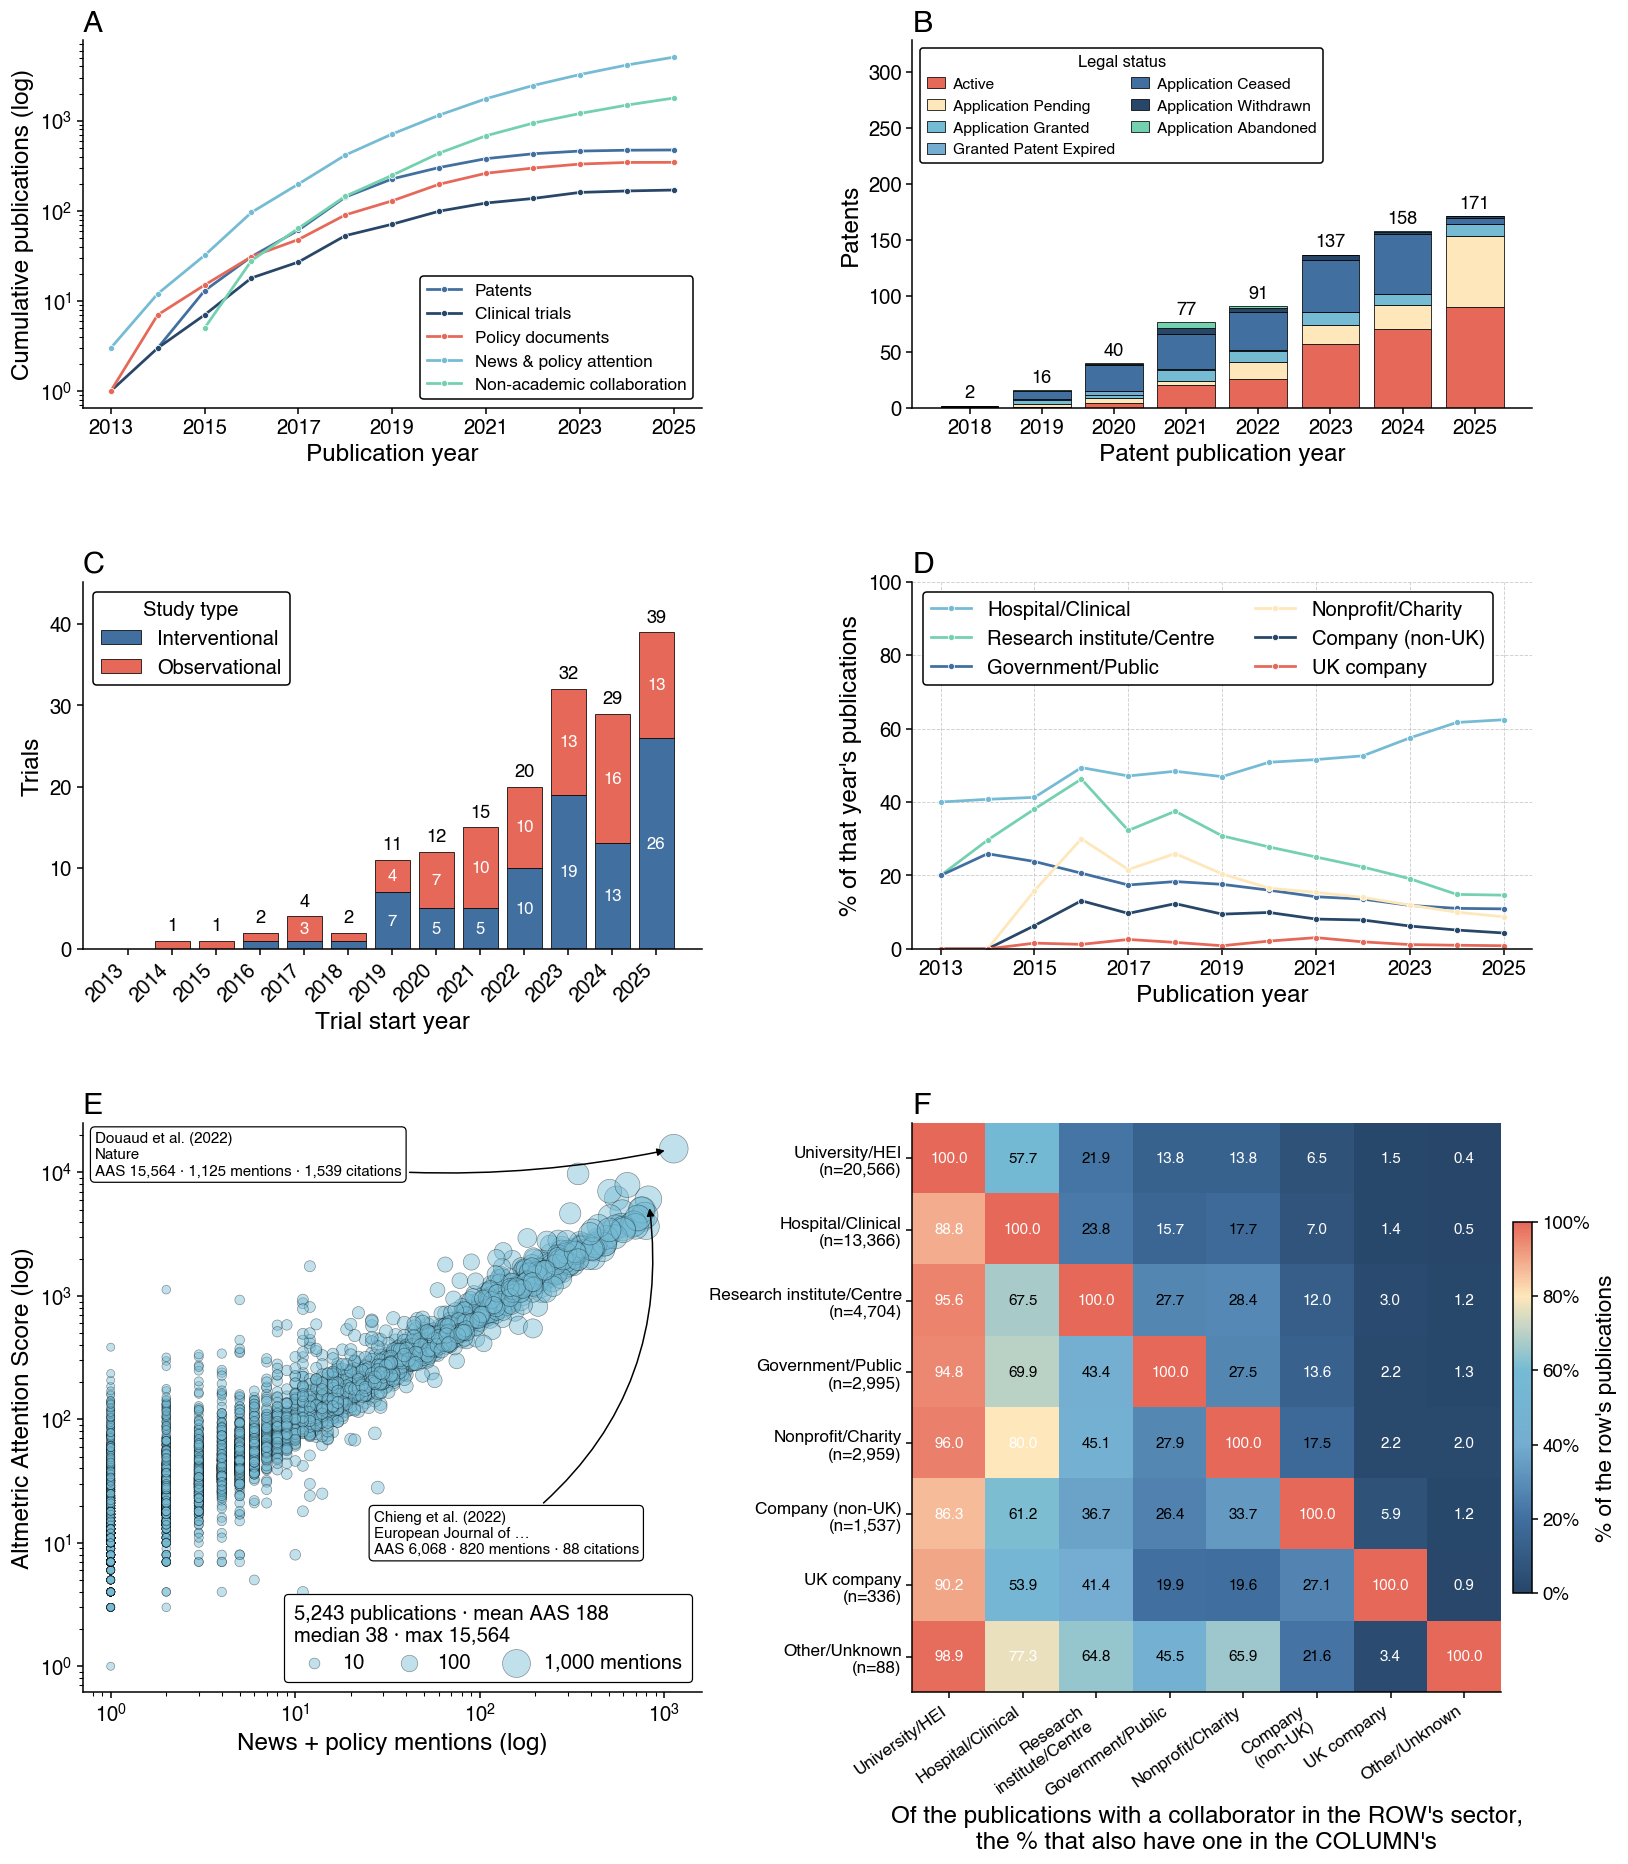

In [5]:
fig_main = NP.figure_main(D)

## 5. SI 1 — Patents

What the patent arm measures beyond the main panel's single bar chart: what became of the
patents, what they are about at two levels, how broad they are, how the mix differs by
country, and how long the paper→patent step takes.

**The patent arm is two figures.** SI 1 is an ordinary 2×2 grid; the RCDC macro-cluster
heatmap has a page of its own below it. That heatmap is 28 rows of category names by seven
clusters — a shape that only reads at full page width — and forcing it into the grid had
pushed SI 1 to twice its natural height and every other panel into a squashed band. Two
figures at ordinary proportions beat one at extraordinary ones.

**SI 1b is the RCDC macro-cluster view** from §4.1 of the source notebook: the ~300 RCDC tags
partitioned into seven research programmes by Louvain community detection on their
co-occurrence graph, each column showing the four tags carrying the most patents in its
cluster. Two things follow from how it is built:

* the matrix is **block-diagonal** — a tag belongs to exactly one cluster — so it reads
  *down the columns*, not across the rows, and its row count is `top_n × 7` exactly. Four
  tags per cluster is 28 rows; five would be 35, which no panel height makes legible.
* it needs `data/analysis/non_academic/patent/paten_rcdc_macro/cluster_label_summary_louvain.csv`,
  an artefact of a job this module does not run. Without that partition the panel says so
  rather than inventing clusters, which cannot be re-derived from the patents alone.

It carries no panel letter: the figure *is* the panel, and stamping an "A" on it would only
invite the reader to look for a B.

**Two panels came out**, and their aggregates are still built if the numbers are wanted:
assignee country (`D["patents"]["countries"]` — the main figure's reach and growth panels
already carry the patent geography) and the paper→patent lag
(`D["patents"]["paper_to_patent_lag"]` — median 1 year over 800 links, which prose can carry
where a heatmap at half width cannot be read at all). Note the country count is once per
patent per country, where `doc/STATE.md` §2's "top US 268" row counts assignee
*occurrences* — different quantities off the same column.

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/04_non_academic/04_02_supplementary_figure_01_patents.pdf


saved output/figures/data_analysis/04_non_academic/04_02_supplementary_figure_01_patents.png


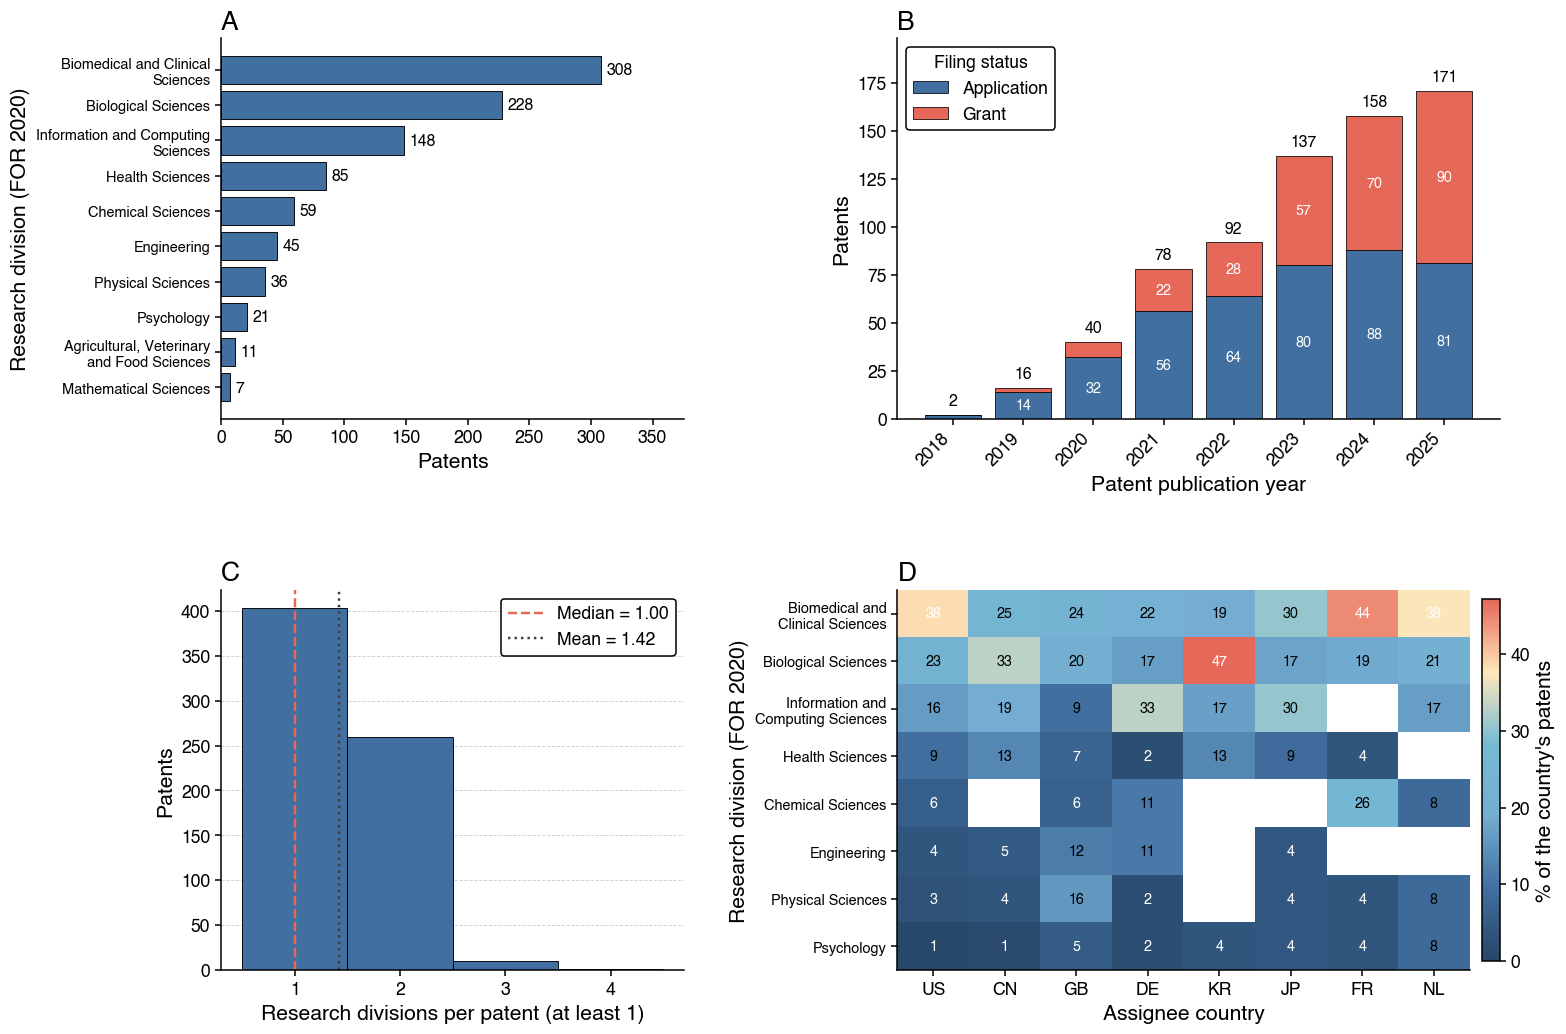

In [6]:
fig_si1 = NP.figure_si_patents(D)


## 6. SI 2 — Clinical trials

Drawn in navy throughout. The arm's own notebook uses LCDS blue `#344874`; navy `#274668`
is the project palette's nearest, so the clinical-trials panels keep the identity they had.

**Panel B is a body map**, not a ranked bar: trials per ICD-10 chapter, placed where the
chapter sits anatomically, with dot area proportional to the trial count. A ranked bar of
condition names answers "which conditions", and panel C already answers that with RCDC —
the body map answers the question a bar cannot, which is *where* the trials that lean on
UK Biobank concentrate. The silhouette is the artwork under
`output/figures/data_analysis/04_non_academic/clinical_trials/human_silhouette/`.

Three things to keep straight when reading it:

* **A trial counts once per chapter it touches**, so the dots do not partition the 195 — a
  trial studying both obesity and heart failure appears in IV and in IX.
* **Neoplasms and infectious disease sit off the body**, under "Systemic". They belong to no
  organ, and placing them on one would be an anatomical claim the data does not make.
* Chapters come from keyword rules over the shipped `mesh_terms` column — 162 of 195 trials
  map to at least one. Panel C asks the same question of RCDC, with the cross-cutting
  research-area tags stop-listed (D11).

**Panel E answers "who runs them", not just "where".** Each trial spreads a weight of 1
evenly across its distinct (country, sector) organisation pairs, so the bars sum to the
number of located trials rather than counting a multi-site trial once per site — the same
fractional accounting as §7 of the source notebook, and the reason the totals print as
whole numbers while the segments behind them are not integers. Sector comes from the
organisation's GRID type where it is committal, and from its name where it is not
(`Facility`, `Other`, untyped), which is how a teaching hospital lands in Healthcare rather
than Academia.

The paper-to-trial lag panel came out to give the body map its two rows. Its distribution
is in `D["trials"]["paper_to_trial_lag"]` — median 3 years over 213 links, with a long
negative tail that is real rather than an error: a trial that started in 1996 and cites a
2023 paper produces a lag of −27 years.

body map: output/figures/data_analysis/04_non_academic/clinical_trials/human_silhouette/silhouette_clean.png not found — dots only


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/04_non_academic/04_03_supplementary_figure_02_clinical_trials.pdf


saved output/figures/data_analysis/04_non_academic/04_03_supplementary_figure_02_clinical_trials.png


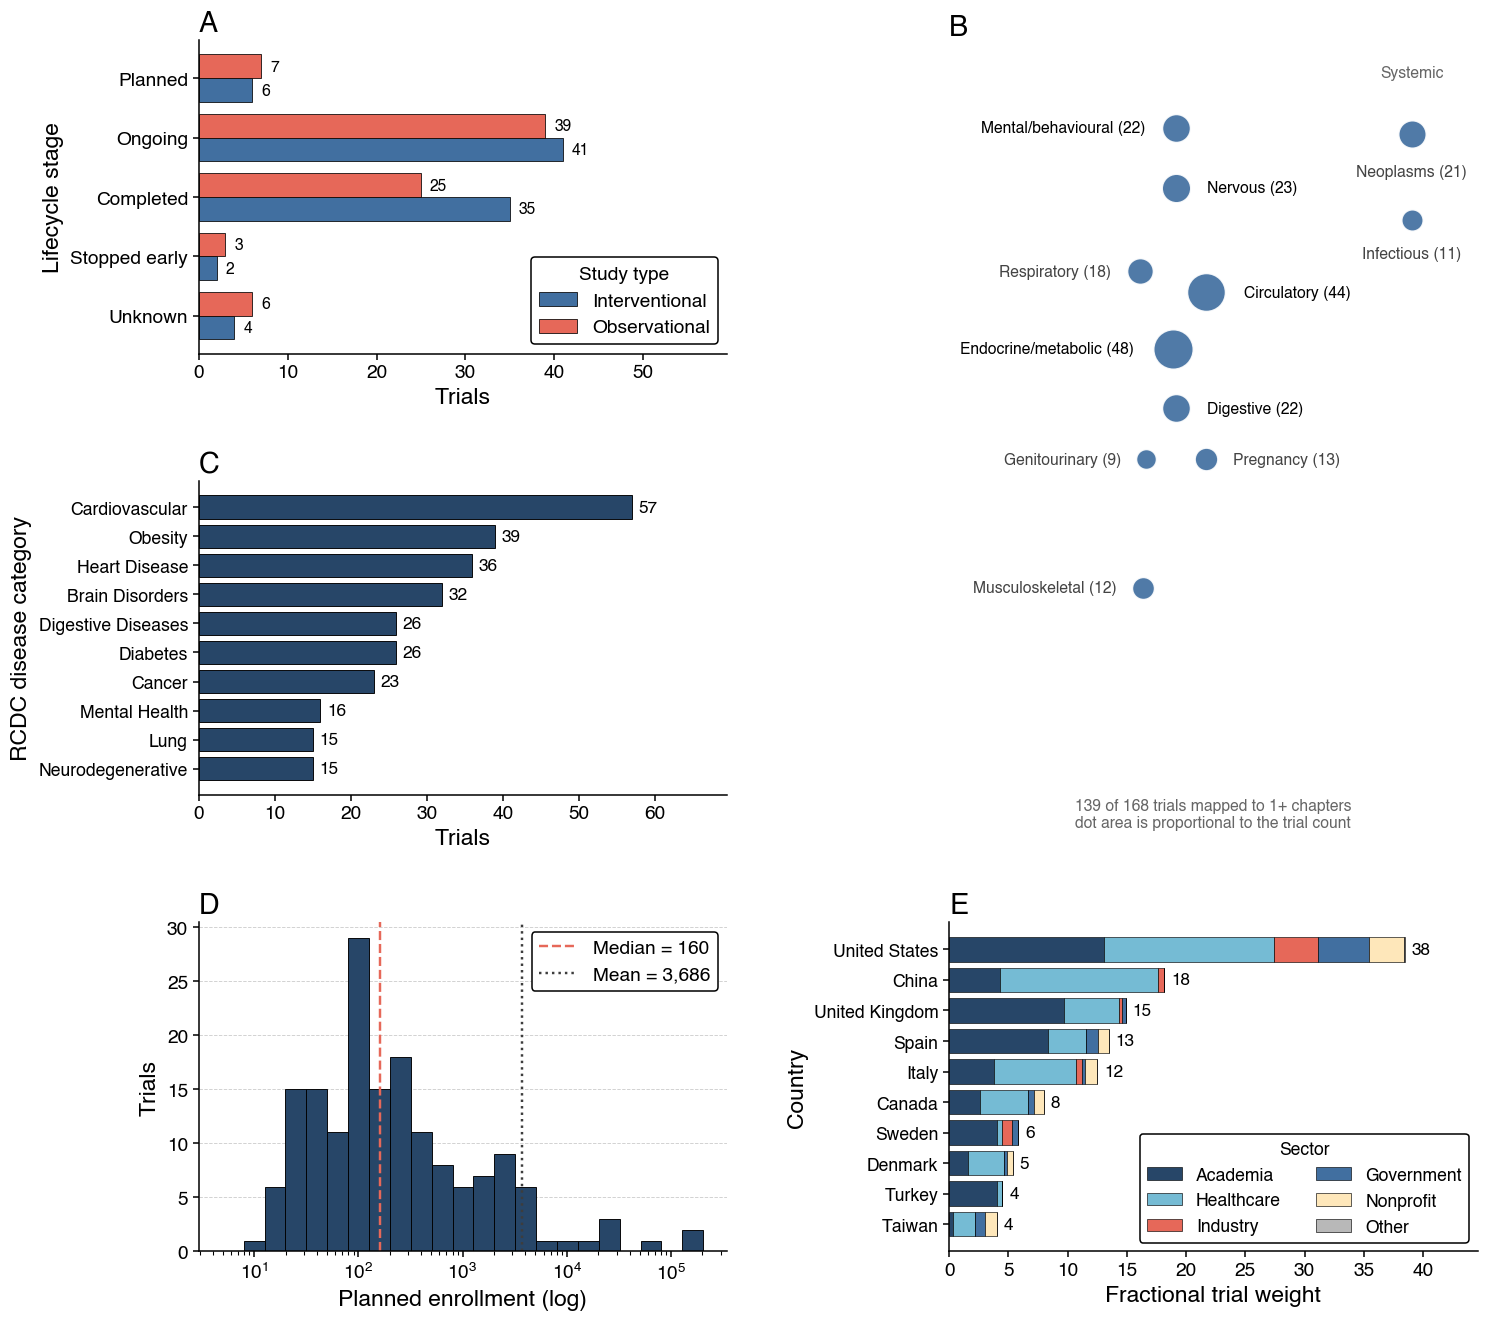

In [7]:
fig_si2 = NP.figure_si_trials(D)

## 7. SI 3 — Policy documents

This is the **Dimensions** policy-citation route (449 documents, 369 publications cited).
It is *not* the same quantity as Altmetric's policy mentions in SI 4 (579 publications) —
the two sources index different document sets and D18 records that they are not
reconcilable. Neither is wrong; they answer slightly different questions and the panels
keep them apart.

**Four panels, drawn in the palette's blue.** The stream palette assigns policy the
palette's red, which is what the main figure's five-line panel A needs to tell five streams
apart. This page is about one stream, so a second hue would carry no information and it is
drawn end to end in `POLICY_PRIMARY`.

**B is now a choropleth.** The ranked country bar's finding was never which country comes
first — it is that a UK resource is cited by policy bodies on five continents, and that the
second and third publishers (the United States and Switzerland, the latter almost entirely
the WHO) are not British. A bar makes the reader assemble that geography from twelve country
names; a map states it. The colour scale is logarithmic, because the counts run 1 to 111
with most countries in single figures and a linear ramp would paint everything outside the
top three the same near-white. Countries with no citing document are grey, not the ramp's
lightest blue — absent and minimal are different claims. The leading five are named with
their counts under the map, since a choropleth cannot be read to a number.
`draw_policy_countries` still draws the bar if it is wanted.

**Two panels came out.** The concentration histogram and the ranked list of most-cited
papers were the page's two weakest claims: the first is a one-line fact — median 1, max 22
over 369 publications — that prose carries better than a log-axis histogram of a
distribution with nothing in its tail, and the second is eight truncated paper titles, which
is a table pretending to be a chart. Both aggregates are still built
(`D["policy"]["policy_docs_per_paper"]`, `D["policy"]["top_cited_papers"]`) and both draw
functions are still in the module.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/04_non_academic/04_04_supplementary_figure_03_policy.pdf


saved output/figures/data_analysis/04_non_academic/04_04_supplementary_figure_03_policy.png


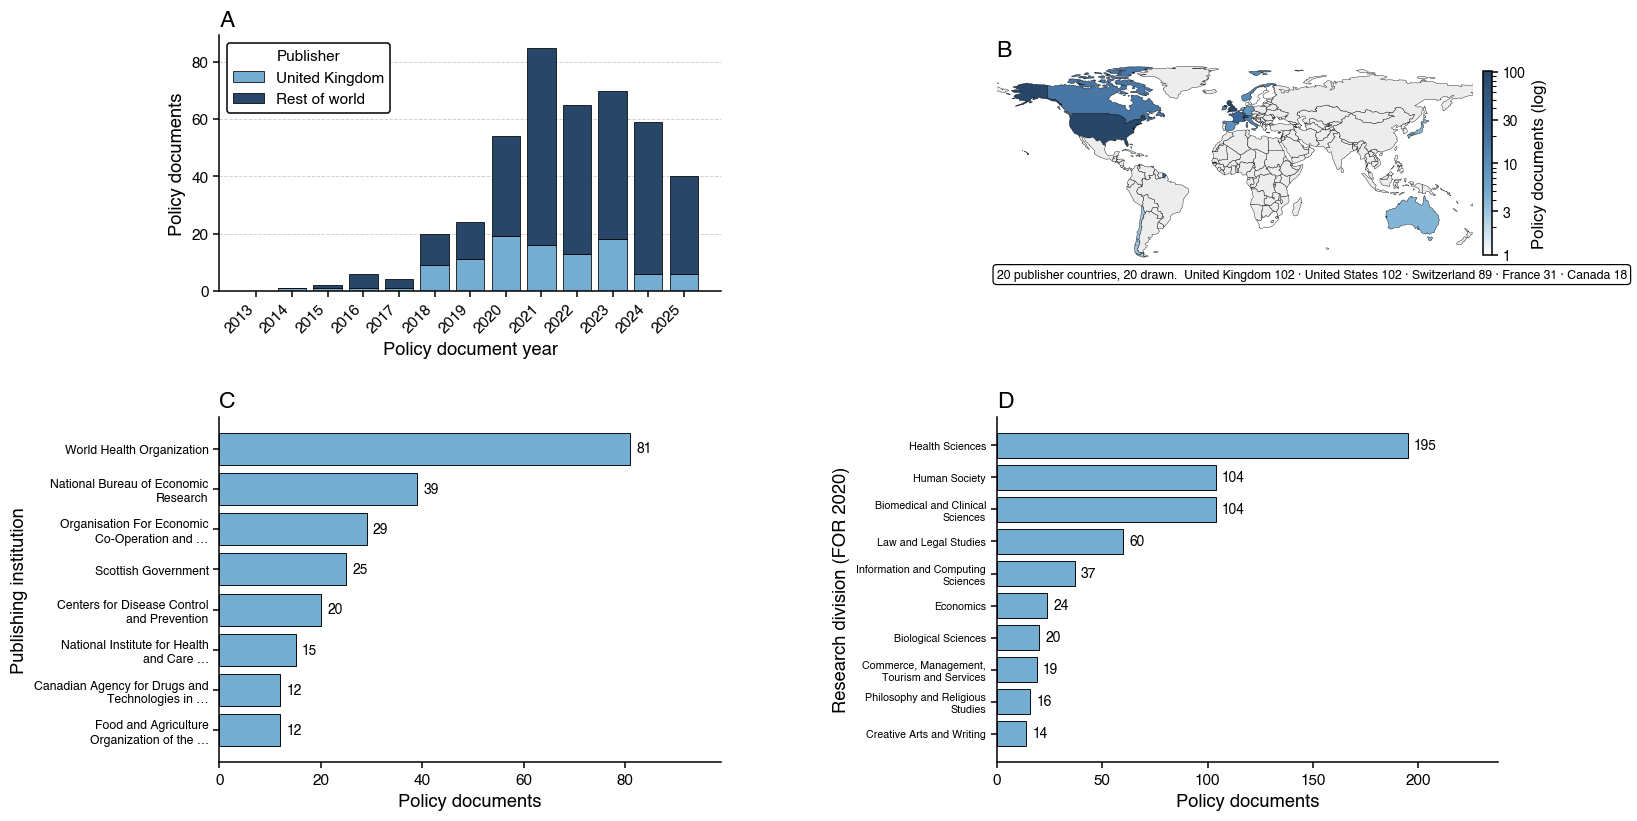

In [8]:
fig_si3 = NP.figure_si_policy(D)

## 8. SI 4 — Altmetric attention

The real Altmetric Explorer export (D18), so panel B's news series is a measurement rather
than the zeros the rebuilt-from-corpus substitute would supply.

**One blue family, not one hue per panel.** The page used to rotate the palette across its
panels — light blue for the score, red for the policy series, green for the
attention-against-citation scatter — which reads as four unrelated charts.
`ATTENTION_PRIMARY` now carries every panel and `ATTENTION_SECONDARY` (navy) appears only in
B and C, where a panel genuinely draws two series and the contrast is doing work. The dashed
red median rule in A is the family's reference colour (`REF_MEDIAN`), not a topic colour,
and stays.

Panel C is a rate, not a total, and it falls across the window. That is mostly an
accumulation artefact — a 2015 paper has had ten years to be written about and a 2025
paper has had months — so it should not be read as declining public interest.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/04_non_academic/04_05_supplementary_figure_04_altmetric.pdf


saved output/figures/data_analysis/04_non_academic/04_05_supplementary_figure_04_altmetric.png


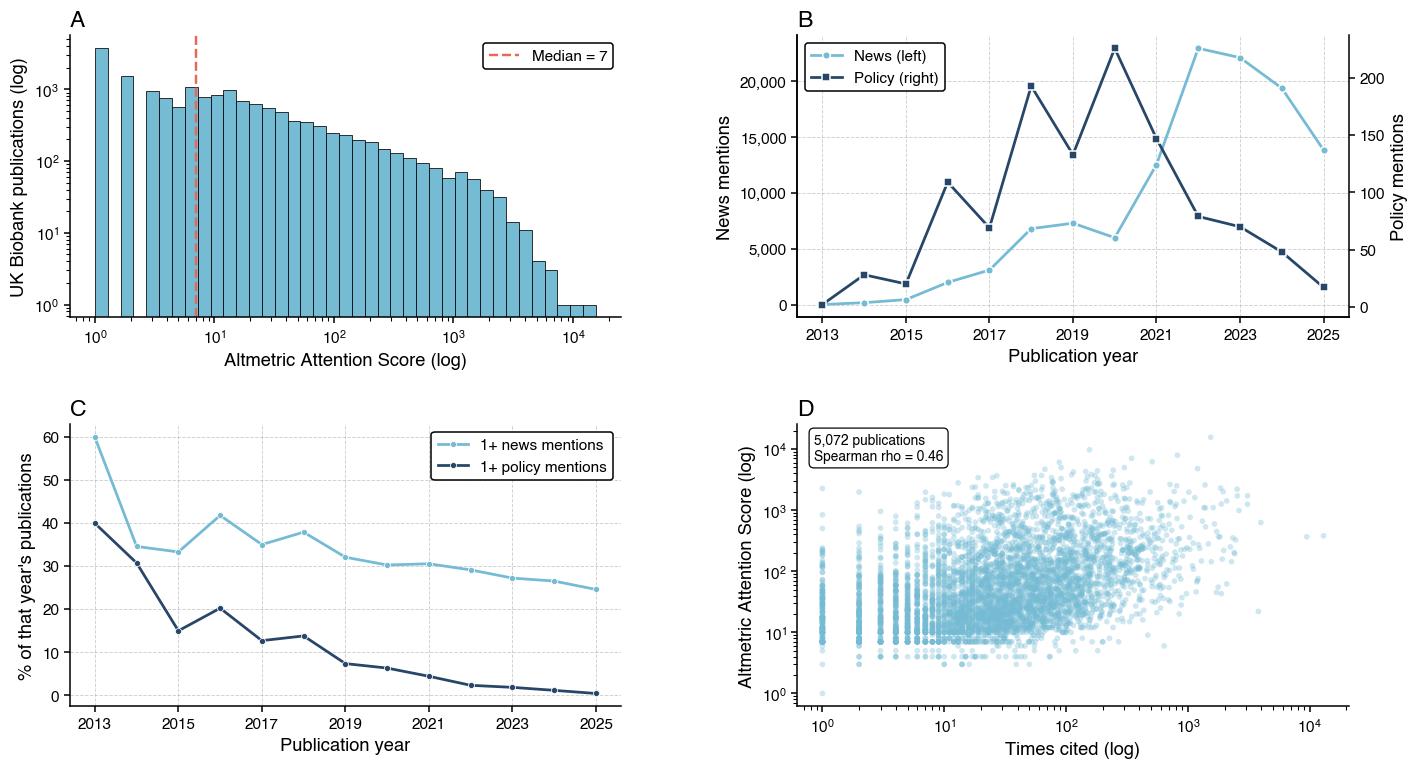

In [9]:
fig_si4 = NP.figure_si_altmetric(D)

## 9. SI 5 — Non-academic collaboration

Panel A's counts are the ones in `doc/STATE.md` §2: University/HEI 68,978 · Hospital/
Clinical 33,873 · Research institute 8,437 · Government 4,491 · Nonprofit 4,233 · Company
non-UK 2,207 · UK company 389 · Other 101.

**The UK-company series carries a known caveat (D27).** After the GRID country correction,
4 organisations — about 15 of the 389 UK-company mentions, 3.9% — are UK bodies that are
not companies. The series is a slight over-count and is the smallest in the panel either
way.

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/04_non_academic/04_06_supplementary_figure_05_collaboration.pdf


saved output/figures/data_analysis/04_non_academic/04_06_supplementary_figure_05_collaboration.png


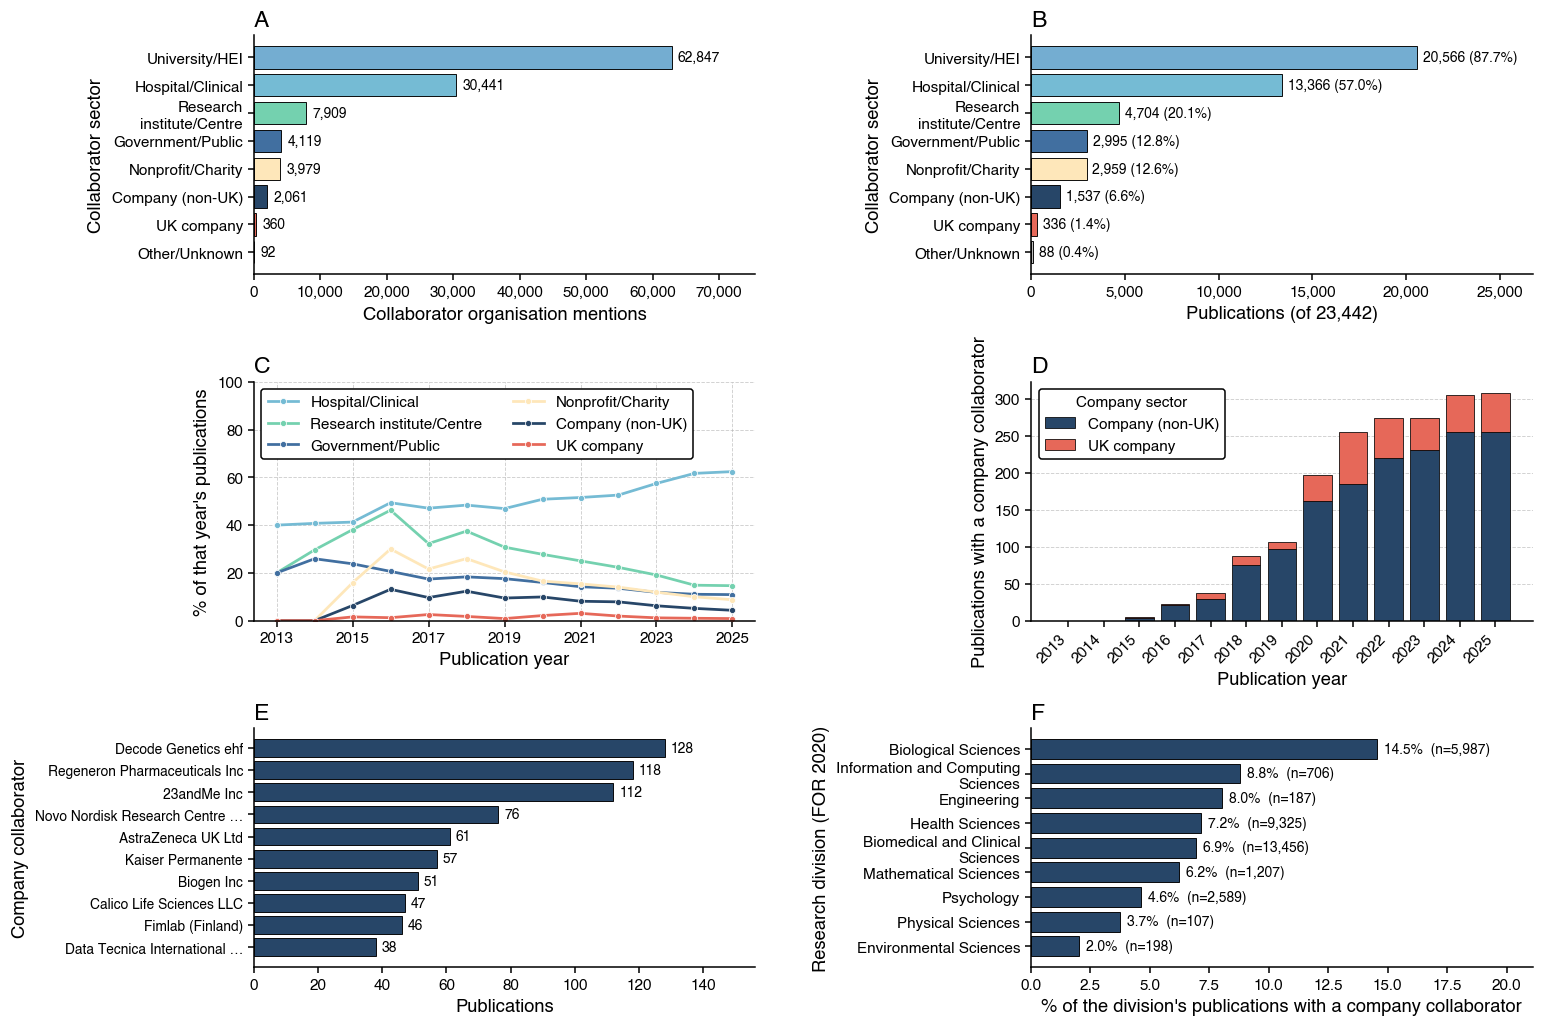

In [10]:
fig_si5 = NP.figure_si_collaboration(D)

## 10. What was written

Every file this notebook produced, with its size, so a re-run can be compared against the
last one rather than trusted.

In [11]:
written = sorted(
    p for p in FIG_DIR.glob("04_[0-9][0-9]_*.*")
    if p.suffix.lower() in {".pdf", ".png"}
)
manifest = pd.DataFrame([
    {"file": P.raw_path(p), "kb": p.stat().st_size // 1024,
     "modified": pd.Timestamp(p.stat().st_mtime, unit="s").round("s")}
    for p in written
])
manifest.to_csv(TABLE_DIR / "panel_manifest.csv", index=False)
print(f"{len(written)} figure files under {P.raw_path(FIG_DIR)} "
      f"({manifest.kb.sum() / 1024:.1f} MB)\n")
display(manifest)

12 figure files under output/figures/data_analysis/04_non_academic (10.7 MB)



,file,kb,modified
0,output/figures/data_analysis/04_non_academic/0...,690,2026-09-22 10:19:51
1,output/figures/data_analysis/04_non_academic/0...,4033,2026-09-22 10:19:54
2,output/figures/data_analysis/04_non_academic/0...,56,2026-09-22 10:19:55
3,output/figures/data_analysis/04_non_academic/0...,981,2026-09-22 10:19:57
4,output/figures/data_analysis/04_non_academic/0...,25,2026-09-22 10:19:58
5,output/figures/data_analysis/04_non_academic/0...,1036,2026-09-22 10:19:59
6,output/figures/data_analysis/04_non_academic/0...,108,2026-09-22 10:20:00
7,output/figures/data_analysis/04_non_academic/0...,1067,2026-09-22 10:20:01
8,output/figures/data_analysis/04_non_academic/0...,86,2026-09-22 10:20:02
9,output/figures/data_analysis/04_non_academic/0...,1539,2026-09-22 10:20:03
